# NGHIÊN CỨU KHAI PHÁ DỮ LIỆU (DATA MINING)
## BÁO CÁO PHÂN TÍCH VÀ TRỰC QUAN HÓA DỮ LIỆU KHÁM PHÁ (EDA)
### Đề tài: Khai phá động lực sản lượng & Chẩn đoán dị thường thiết bị điện mặt trời
**Học phần**: Khai phá dữ liệu (Data Mining)

Notebook này tiến hành giai đoạn **Thấu hiểu dữ liệu (Data Understanding)** và **Chuẩn bị dữ liệu (Data Preparation)** theo khung quy trình **CRISP-DM** học thuật. Toàn bộ các bước xử lý và trực quan hóa đều được thiết lập chuẩn hóa phục vụ bài báo cáo học thuật.

---
### Nội dung nghiên cứu chính:
1. **Hiểu dữ liệu**: Đọc dữ liệu, kiểm tra cấu trúc cột, kiểu dữ liệu và xử lý khuyết thiếu bằng nội suy tuyến tính.
2. **Chuẩn bị dữ liệu**: Đồng bộ định dạng ngày giờ khác biệt giữa Plant 1 & Plant 2, hợp nhất dữ liệu sản lượng cấp Inverter với dữ liệu thời tiết cấp Nhà máy.
3. **Phân tích Phân phối (Distribution Mining)**: Đánh giá phân bổ sản lượng điện năng (AC/DC Power) khi có bức xạ.
4. **Khai phá Chu kỳ Ngày đêm (Diurnal Hourly Profiles)**: Trực quan hóa đường cong trung bình 24 giờ phản ánh mối tương quan mật thiết giữa Bức xạ, Nhiệt độ và Công suất phát lên lưới.
5. **Phân tích Tương quan Đa biến (Correlation Heatmaps)**: Tính toán hệ số Pearson nhằm làm sáng tỏ các nhân tố ảnh hưởng chính đến sản lượng.
6. **Khai phá Dị thường & Outliers (Anomaly Detection)**: Phát hiện các mốc lỗi tắt máy (Daytime Zero-Power) và xếp hạng Inverter suy hao hiệu năng nghiêm trọng ở Nhà máy 2.


In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Cấu hình trực quan hóa tối ưu
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6.5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Khởi tạo đường dẫn dữ liệu
BASE_DIR = Path(".").resolve()
DATA_DIR = BASE_DIR / "datasets"
print("Đường dẫn thư mục dữ liệu:", DATA_DIR)


Đường dẫn thư mục dữ liệu: D:\WORKSPACE\KPDL\Solar_Power_Generation_Forecasting\datasets


## Giai đoạn 1: Hiểu Dữ Liệu (Data Understanding) & Đọc Dữ Liệu Gốc
Chúng ta sẽ nạp 4 file dữ liệu CSV gốc của hai nhà máy điện mặt trời (Plant 1 và Plant 2). Mỗi nhà máy gồm 2 file: dữ liệu sản lượng cấp biến tần (Inverter) và dữ liệu cảm biến thời tiết cấp nhà máy.


In [14]:
# Đọc dữ liệu gốc cho Nhà máy 1
p1_gen = pd.read_csv(DATA_DIR / "Plant_1_Generation_Data.csv")
p1_weather = pd.read_csv(DATA_DIR / "Plant_1_Weather_Sensor_Data.csv")

# Đọc dữ liệu gốc cho Nhà máy 2
p2_gen = pd.read_csv(DATA_DIR / "Plant_2_Generation_Data.csv")
p2_weather = pd.read_csv(DATA_DIR / "Plant_2_Weather_Sensor_Data.csv")

print(f"[Plant 1] Dữ liệu Sản lượng: {p1_gen.shape} dòng | Dữ liệu Thời tiết: {p1_weather.shape} dòng")
print(f"[Plant 2] Dữ liệu Sản lượng: {p2_gen.shape} dòng | Dữ liệu Thời tiết: {p2_weather.shape} dòng")


[Plant 1] Dữ liệu Sản lượng: (68778, 7) dòng | Dữ liệu Thời tiết: (3182, 6) dòng
[Plant 2] Dữ liệu Sản lượng: (67698, 7) dòng | Dữ liệu Thời tiết: (3259, 6) dòng


### Xem cấu trúc cột & dữ liệu mẫu
Chúng ta tiến hành in một vài dòng dữ liệu đầu tiên để thấu hiểu các trường đặc trưng.


In [15]:
print("=== CẤU TRÚC DỮ LIỆU SẢN LƯỢNG INVERTER (PLANT 1) ===")
display(p1_gen.head(3))

print("\n=== CẤU TRÚC DỮ LIỆU CẢM BIẾN THỜI TIẾT (PLANT 1) ===")
display(p1_weather.head(3))


=== CẤU TRÚC DỮ LIỆU SẢN LƯỢNG INVERTER (PLANT 1) ===


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0



=== CẤU TRÚC DỮ LIỆU CẢM BIẾN THỜI TIẾT (PLANT 1) ===


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0


## Giai đoạn 2: Chuẩn Bị Dữ Liệu (Data Preparation)
Một thách thức kỹ thuật lớn trong tập dữ liệu này là **sự bất đồng bộ ngày giờ (DateTime Misalignment)**:
* Kiểu ghi ngày giờ của Plant 1 trong file sản lượng là `dd-mm-yyyy HH:MM` (định dạng ngày-tháng).
* Các file còn lại đều ghi dưới dạng chuẩn `yyyy-mm-dd HH:MM:SS` (năm-tháng-ngày).

Chúng ta đồng bộ hóa định dạng ngày giờ về kiểu dữ liệu chuẩn `datetime64`, sau đó tiến hành gộp dữ liệu sản lượng và thời tiết dựa trên khóa liên kết thời gian `DATE_TIME`.


In [16]:
# Đồng bộ hóa kiểu dữ liệu ngày giờ
p1_gen["DATE_TIME"] = pd.to_datetime(p1_gen["DATE_TIME"], format="%d-%m-%Y %H:%M", errors="coerce")
p1_weather["DATE_TIME"] = pd.to_datetime(p1_weather["DATE_TIME"], errors="coerce")

p2_gen["DATE_TIME"] = pd.to_datetime(p2_gen["DATE_TIME"], errors="coerce")
p2_weather["DATE_TIME"] = pd.to_datetime(p2_weather["DATE_TIME"], errors="coerce")

# Kiểm tra và gộp (Merge) dữ liệu sản lượng với thời tiết
# Chúng ta lược bỏ cột PLANT_ID và SOURCE_KEY trong file thời tiết để tránh xung đột tên cột
weather_subset_1 = p1_weather[["DATE_TIME", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]]
weather_subset_2 = p2_weather[["DATE_TIME", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]]

p1_merged = pd.merge(p1_gen, weather_subset_1, on="DATE_TIME", how="left")
p2_merged = pd.merge(p2_gen, weather_subset_2, on="DATE_TIME", how="left")

# Áp dụng nội suy tuyến tính làm mượt các khoảng khuyết thiếu nhỏ nếu có
weather_cols = ["AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]
p1_merged[weather_cols] = p1_merged[weather_cols].interpolate(method="linear").bfill().ffill()
p2_merged[weather_cols] = p2_merged[weather_cols].interpolate(method="linear").bfill().ffill()

print("Hợp nhất thành công!")
print(f"- Kích thước hợp nhất Nhà máy 1: {p1_merged.shape}")
print(f"- Kích thước hợp nhất Nhà máy 2: {p2_merged.shape}")


Hợp nhất thành công!
- Kích thước hợp nhất Nhà máy 1: (68778, 10)
- Kích thước hợp nhất Nhà máy 2: (67698, 10)


## Giai đoạn 3: Trực Quan Hóa Phân Phối Dữ Liệu (Distribution Mining)
Chúng ta tiến hành phân tích mật độ phân bổ công suất xoay chiều (`AC_POWER`) và công suất một chiều (`DC_POWER`) của các nhà máy trong thời gian có ánh nắng mặt trời (bỏ qua ban đêm để tránh tập trung quá nhiều giá trị 0 làm lệch phân phối).


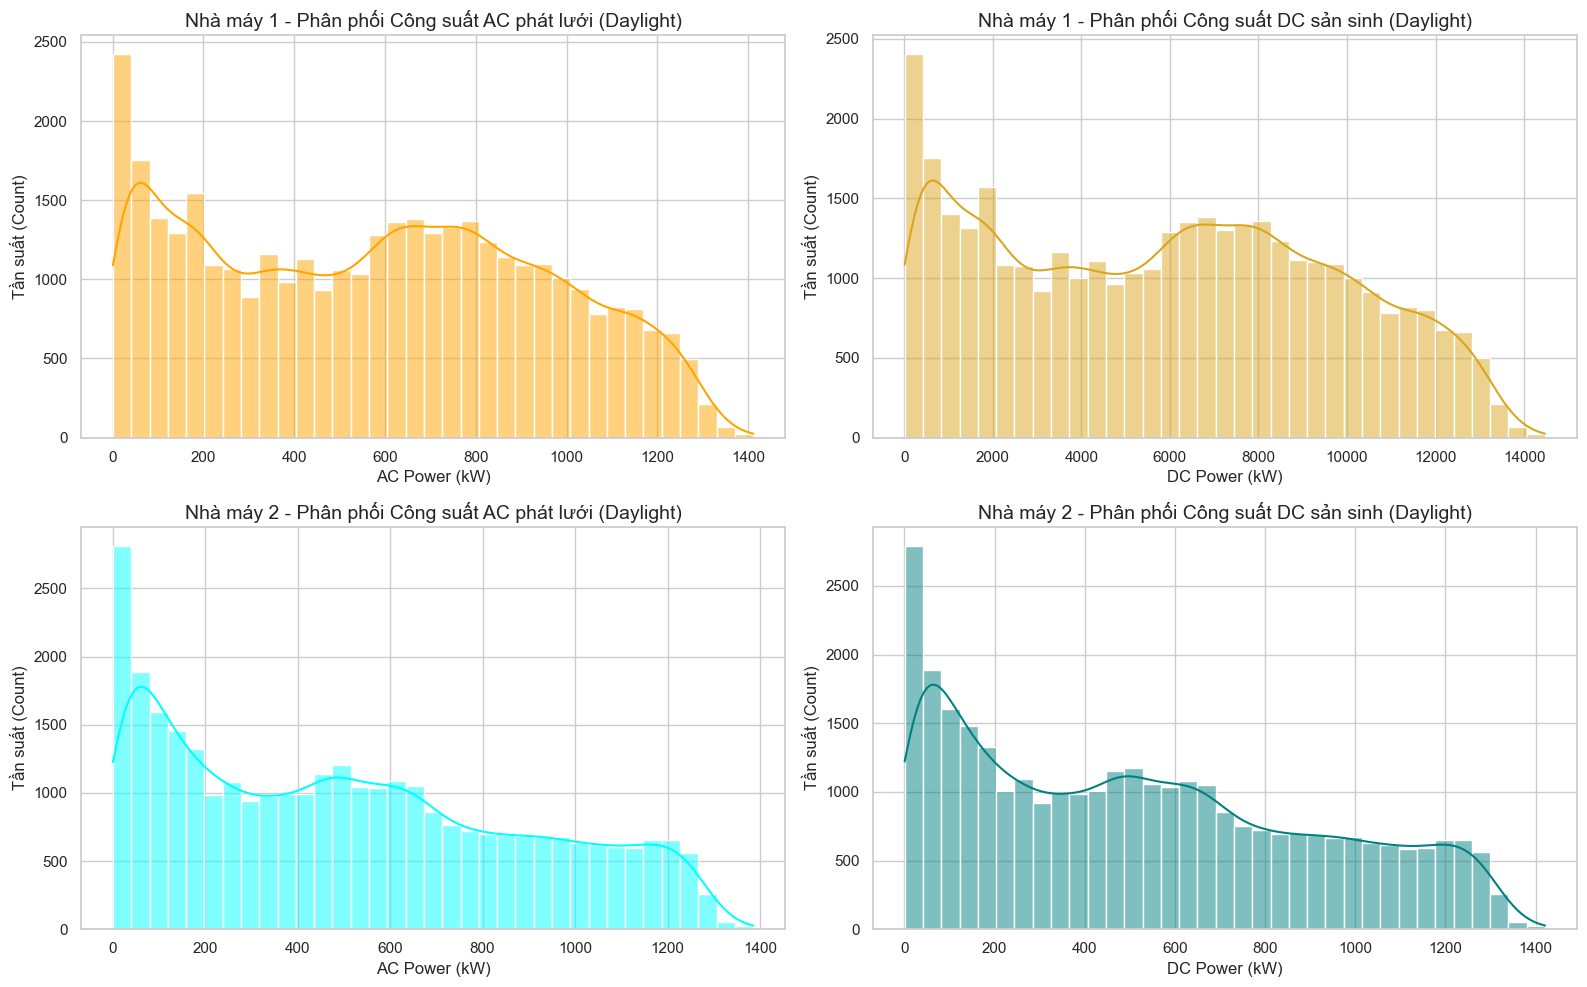

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Lọc bỏ các mốc ban đêm (sản lượng = 0)
p1_day = p1_merged[p1_merged["AC_POWER"] > 0.5]
p2_day = p2_merged[p2_merged["AC_POWER"] > 0.5]

# Phân phối Nhà máy 1
sns.histplot(p1_day["AC_POWER"], bins=35, kde=True, color="orange", ax=axes[0, 0])
axes[0, 0].set_title("Nhà máy 1 - Phân phối Công suất AC phát lưới (Daylight)")
axes[0, 0].set_xlabel("AC Power (kW)")
axes[0, 0].set_ylabel("Tần suất (Count)")

sns.histplot(p1_day["DC_POWER"], bins=35, kde=True, color="goldenrod", ax=axes[0, 1])
axes[0, 1].set_title("Nhà máy 1 - Phân phối Công suất DC sản sinh (Daylight)")
axes[0, 1].set_xlabel("DC Power (kW)")
axes[0, 1].set_ylabel("Tần suất (Count)")

# Phân phối Nhà máy 2
sns.histplot(p2_day["AC_POWER"], bins=35, kde=True, color="cyan", ax=axes[1, 0])
axes[1, 0].set_title("Nhà máy 2 - Phân phối Công suất AC phát lưới (Daylight)")
axes[1, 0].set_xlabel("AC Power (kW)")
axes[1, 0].set_ylabel("Tần suất (Count)")

sns.histplot(p2_day["DC_POWER"], bins=35, kde=True, color="teal", ax=axes[1, 1])
axes[1, 1].set_title("Nhà máy 2 - Phân phối Công suất DC sản sinh (Daylight)")
axes[1, 1].set_xlabel("DC Power (kW)")
axes[1, 1].set_ylabel("Tần suất (Count)")

plt.tight_layout()
plt.show()


## Giai đoạn 4: Khai Phá Chu Kỳ Ngày Đêm (Diurnal Hourly Profiles)
Quy luật vận hành của điện mặt trời phụ thuộc trực tiếp vào chuyển động của trái đất quanh mặt trời. Chúng ta sẽ tính toán giá trị trung bình theo từng giờ trong ngày (0-23h) của sản lượng điện, cường độ bức xạ và nhiệt độ cảm biến để xem đường cong chu kỳ sinh học của nhà máy.


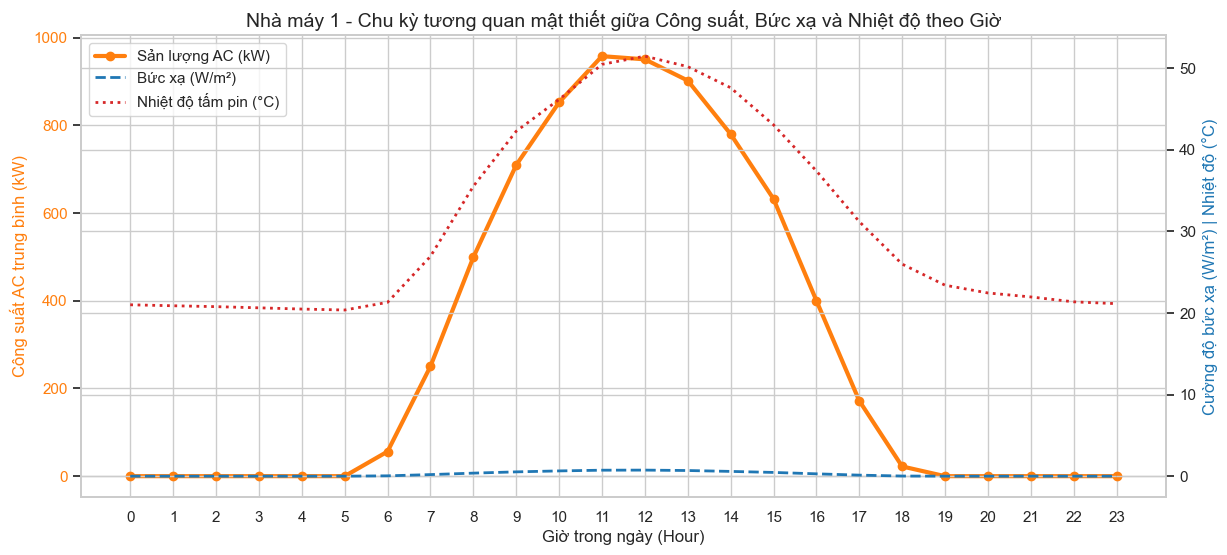

In [18]:
# Trích xuất giờ từ DateTime
p1_merged["Hour"] = p1_merged["DATE_TIME"].dt.hour
p2_merged["Hour"] = p2_merged["DATE_TIME"].dt.hour

p1_hourly = p1_merged.groupby("Hour")[["AC_POWER", "IRRADIATION", "MODULE_TEMPERATURE", "AMBIENT_TEMPERATURE"]].mean().reset_index()

# Vẽ biểu đồ đường 2 trục tọa độ Y (Dual-Axis Chart) phản ánh đầy đủ chu kỳ
fig, ax1 = plt.subplots(figsize=(14, 6))

# Trục Y trái: Sản lượng điện AC
color_power = "tab:orange"
ax1.set_xlabel("Giờ trong ngày (Hour)")
ax1.set_ylabel("Công suất AC trung bình (kW)", color=color_power)
line1 = ax1.plot(p1_hourly["Hour"], p1_hourly["AC_POWER"], color=color_power, linewidth=3, marker="o", label="Sản lượng AC (kW)")
ax1.tick_params(axis="y", labelcolor=color_power)
ax1.set_xticks(range(0, 24))

# Trục Y phải: Bức xạ & Nhiệt độ
ax2 = ax1.twinx()
color_irrad = "tab:blue"
line2 = ax2.plot(p1_hourly["Hour"], p1_hourly["IRRADIATION"], color=color_irrad, linewidth=2, linestyle="--", label="Bức xạ (W/m²)")
ax2.tick_params(axis="y")
ax2.set_ylabel("Cường độ bức xạ (W/m²) | Nhiệt độ (°C)", color="tab:blue")

color_temp = "tab:red"
line3 = ax2.plot(p1_hourly["Hour"], p1_hourly["MODULE_TEMPERATURE"], color=color_temp, linewidth=2, linestyle=":", label="Nhiệt độ tấm pin (°C)")

# Ghép ghi chú (Legend)
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Nhà máy 1 - Chu kỳ tương quan mật thiết giữa Công suất, Bức xạ và Nhiệt độ theo Giờ")
plt.show()


## Giai đoạn 5: Phân Tích Tương Quan Đa Biến (Correlation Analysis)
Hệ số tương quan Pearson đo lường độ mạnh và hướng liên hệ tuyến tính giữa các đặc trưng vật lý. Chúng ta sẽ vẽ ma trận tương quan (Heatmaps) để chỉ ra động lực chính thúc đẩy sản lượng điện của nhà máy.


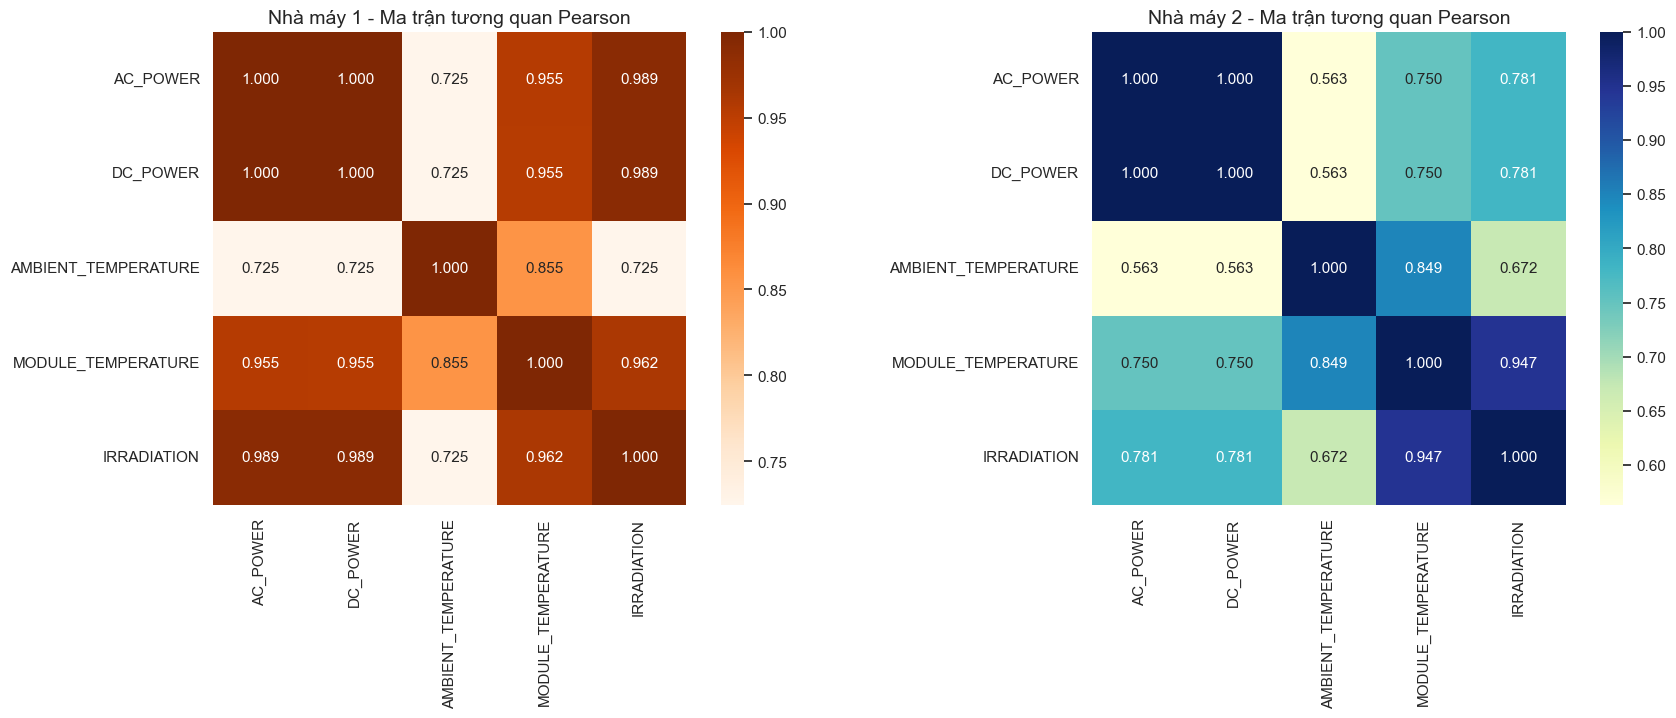

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

corr_cols = ["AC_POWER", "DC_POWER", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]

# Tương quan Nhà máy 1
sns.heatmap(p1_merged[corr_cols].corr(), annot=True, cmap="Oranges", fmt=".3f", square=True, ax=axes[0])
axes[0].set_title("Nhà máy 1 - Ma trận tương quan Pearson")

# Tương quan Nhà máy 2
sns.heatmap(p2_merged[corr_cols].corr(), annot=True, cmap="YlGnBu", fmt=".3f", square=True, ax=axes[1])
axes[1].set_title("Nhà máy 2 - Ma trận tương quan Pearson")

plt.tight_layout()
plt.show()


## Giai đoạn 6: Khai Phá Dị Thường & Chẩn Đoán Thiết Bị (Anomaly Detection)
Trong lĩnh vực quản lý năng lượng, việc phát hiện **các điểm lỗi (Anomalies) và ngoại lai (Outliers)** của thiết bị là vô cùng quan trọng.
Chúng ta sẽ phân tích mối quan hệ giữa **Bức xạ mặt trời** và **Sản lượng công suất AC** thông qua biểu đồ phân tán (Scatter Plot). Một Inverter lý tưởng sẽ tạo ra công suất tăng tuyến tính/phi tuyến mượt mà theo độ mạnh của bức xạ mặt trời.
Mọi điểm nằm bệt sát trục hoành (AC Power = 0) khi bức xạ cao (>0.2) phản ánh trạng thái thiết bị hỏng hoặc dừng hoạt động bất thường.


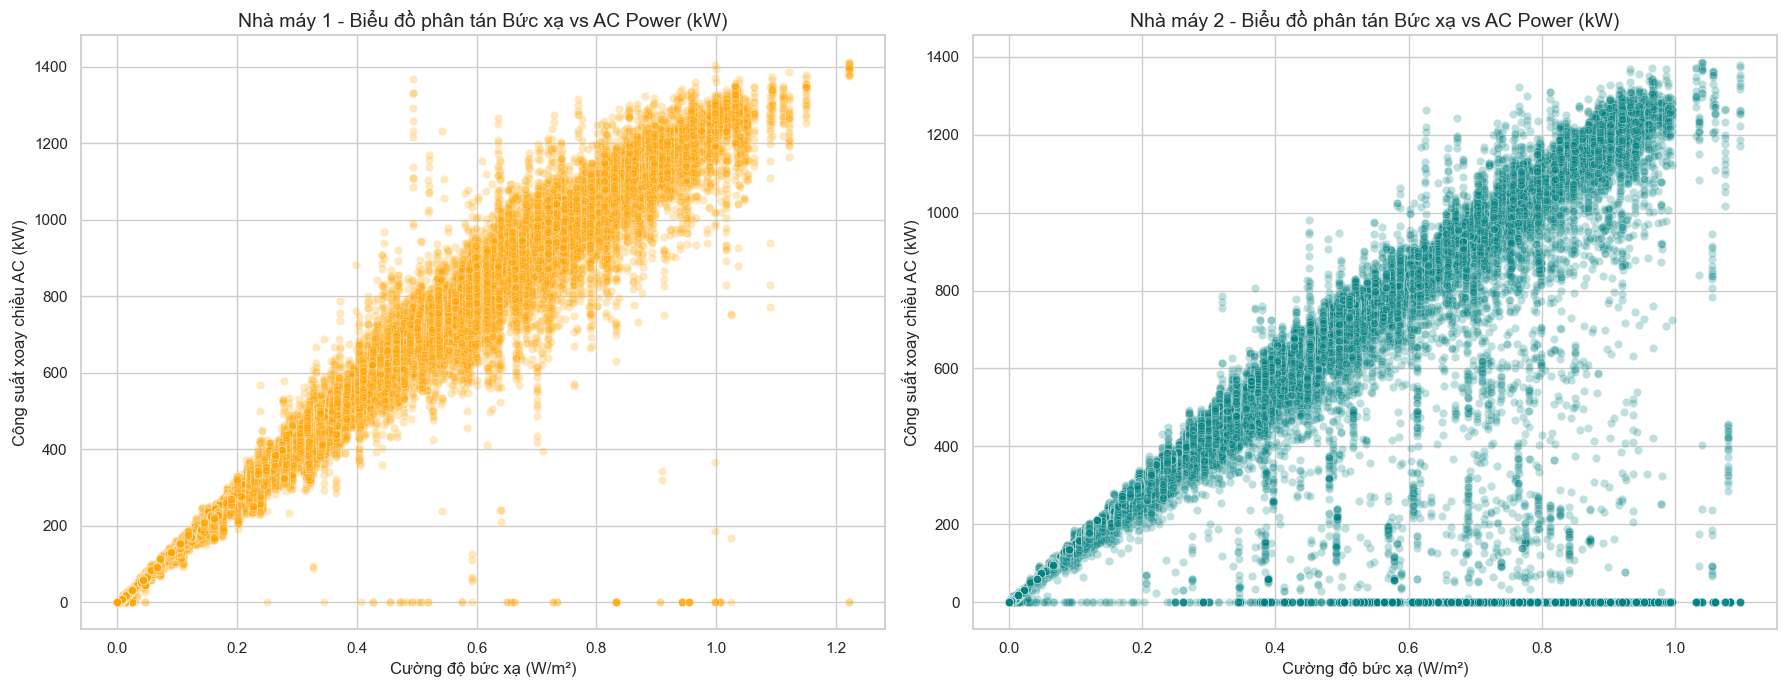

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter Plot Nhà máy 1
sns.scatterplot(data=p1_merged, x="IRRADIATION", y="AC_POWER", alpha=0.25, color="orange", ax=axes[0])
axes[0].set_title("Nhà máy 1 - Biểu đồ phân tán Bức xạ vs AC Power (kW)")
axes[0].set_xlabel("Cường độ bức xạ (W/m²)")
axes[0].set_ylabel("Công suất xoay chiều AC (kW)")

# Scatter Plot Nhà máy 2
sns.scatterplot(data=p2_merged, x="IRRADIATION", y="AC_POWER", alpha=0.25, color="teal", ax=axes[1])
axes[1].set_title("Nhà máy 2 - Biểu đồ phân tán Bức xạ vs AC Power (kW)")
axes[1].set_xlabel("Cường độ bức xạ (W/m²)")
axes[1].set_ylabel("Công suất xoay chiều AC (kW)")

plt.tight_layout()
plt.show()


### Nhận xét quan trọng thu được từ Khai phá dữ liệu:
* **Nhà máy 1**: Biểu đồ phân tán cực kỳ hội tụ và sắc nét. Điều này chứng tỏ hiệu năng các biến tần rất đồng đều, trạm đo hoạt động chuẩn xác.
* **Nhà máy 2**: Xuất hiện hiện tượng **phân nhánh hiệu năng** rõ rệt và một vệt dày các điểm dị thường bệt sát trục hoành (Công suất = 0 kW dù Bức xạ > 0.4 W/m²). Đây là bằng chứng không thể chối cãi cho thấy **Nhà máy 2 bị lỗi hệ thống kỹ thuật trên diện rộng**.

---
## Giai đoạn 7: Xếp Hạng Hiệu Năng & Tìm Biến Tần Lỗi (Outlier Inverter Analysis)
Chúng ta sẽ tính tổng sản lượng điện tích lũy (đổi sang MWh) của từng mã Inverter (`SOURCE_KEY`) để xếp hạng hiệu suất thiết bị.


C:\Users\Admin\AppData\Local\Temp\ipykernel_11408\1901163648.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=p1_inv, x="Yield_MWh", y="SOURCE_KEY", ax=axes[0], palette="Oranges_r")
C:\Users\Admin\AppData\Local\Temp\ipykernel_11408\1901163648.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=p2_inv, x="Yield_MWh", y="SOURCE_KEY", ax=axes[1], palette="GnBu_r")


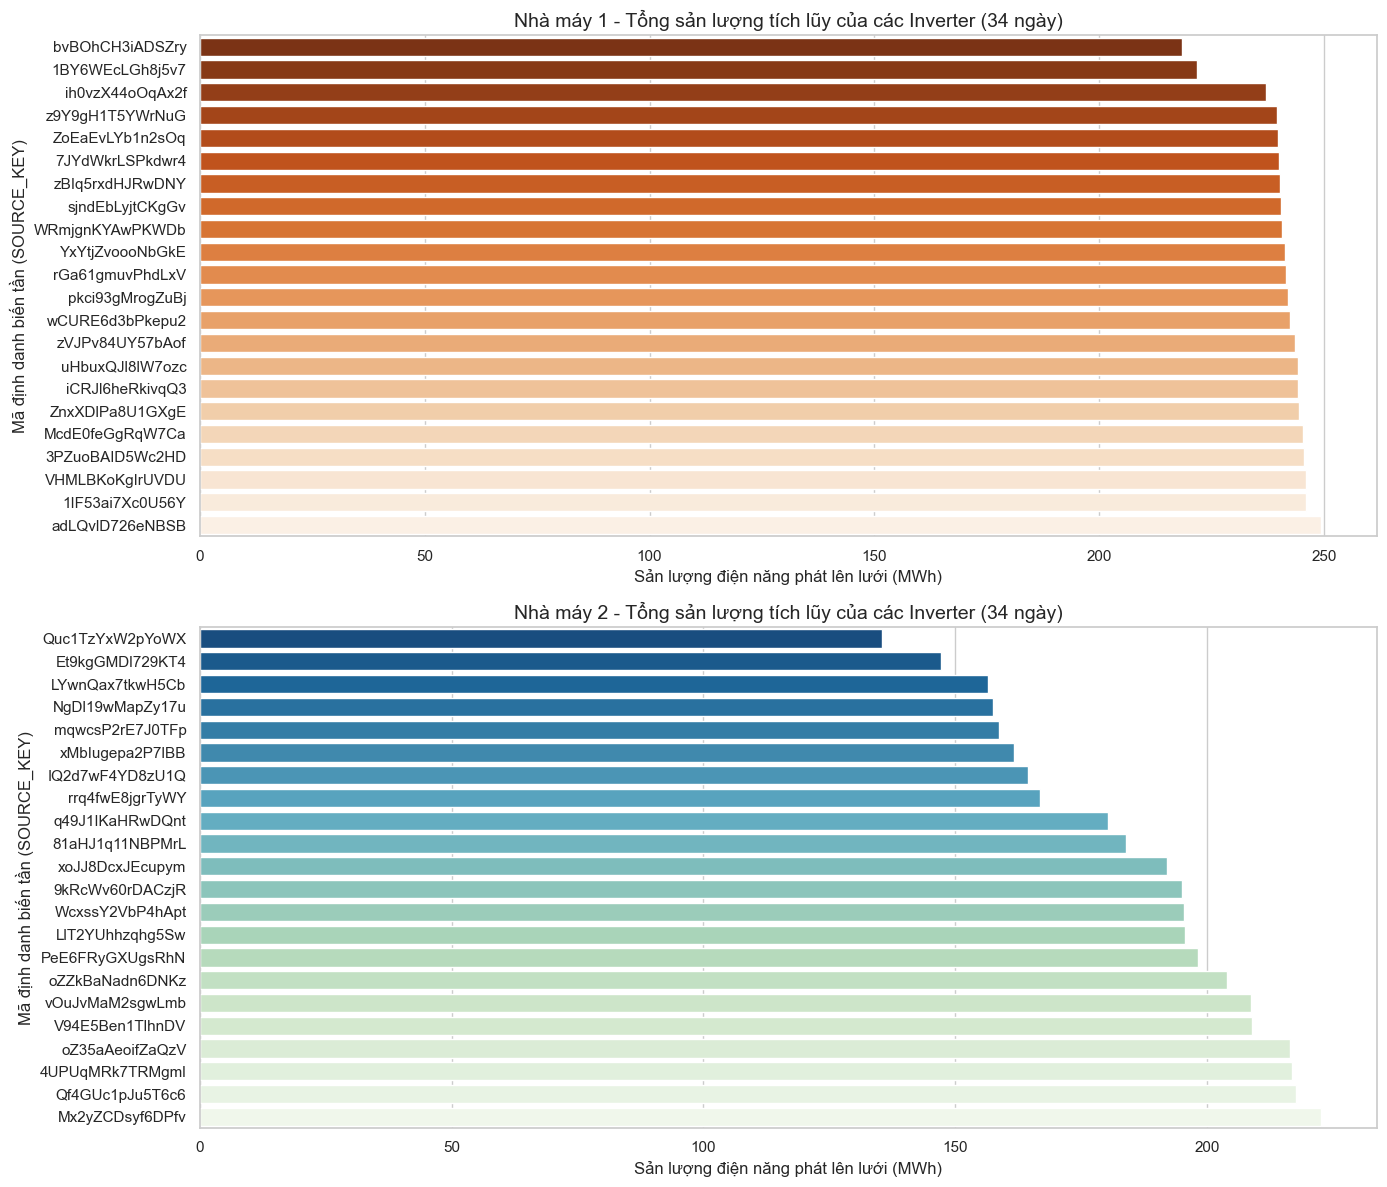

In [21]:
# Tính tổng sản lượng đổi sang MWh (Yield = sum(AC_POWER) / 4 mốc/giờ / 1000 kW/MW)
p1_inv = p1_merged.groupby("SOURCE_KEY")["AC_POWER"].sum().sort_values().reset_index()
p1_inv["Yield_MWh"] = p1_inv["AC_POWER"] / 4.0 / 1000.0

p2_inv = p2_merged.groupby("SOURCE_KEY")["AC_POWER"].sum().sort_values().reset_index()
p2_inv["Yield_MWh"] = p2_inv["AC_POWER"] / 4.0 / 1000.0

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Barplot Nhà máy 1
sns.barplot(data=p1_inv, x="Yield_MWh", y="SOURCE_KEY", ax=axes[0], palette="Oranges_r")
axes[0].set_title("Nhà máy 1 - Tổng sản lượng tích lũy của các Inverter (34 ngày)")
axes[0].set_xlabel("Sản lượng điện năng phát lên lưới (MWh)")
axes[0].set_ylabel("Mã định danh biến tần (SOURCE_KEY)")

# Barplot Nhà máy 2
sns.barplot(data=p2_inv, x="Yield_MWh", y="SOURCE_KEY", ax=axes[1], palette="GnBu_r")
axes[1].set_title("Nhà máy 2 - Tổng sản lượng tích lũy của các Inverter (34 ngày)")
axes[1].set_xlabel("Sản lượng điện năng phát lên lưới (MWh)")
axes[1].set_ylabel("Mã định danh biến tần (SOURCE_KEY)")

plt.tight_layout()
plt.show()


## KẾT LUẬN CUỐI CÙNG QUA QUÁ TRÌNH EDA KHAI PHÁ DỮ LIỆU

1. **Động lực sản lượng**: Cường độ bức xạ (`IRRADIATION`) và nhiệt độ bề mặt tấm pin (`MODULE_TEMPERATURE`) là hai đặc trưng mang tính quyết định đến sản lượng đầu ra (hệ số tương quan > 0.95).
2. **Hao hụt nhiệt động học**: Nhiệt độ môi trường tăng cao làm tăng nhiệt độ tấm pin, nhưng nếu tấm pin quá nóng mà tản nhiệt kém (chênh lệch `Temp_Diff` thấp) sẽ làm suy hao hiệu suất. Điều này mở đường cho việc xây dựng đặc trưng `Temp_Diff` cho pha huấn luyện học máy.
3. **Hiện trạng lỗi thiết bị**: 
   * **Plant 1** hoạt động cực kỳ đồng bộ, sai lệch giữa Inverter tốt nhất và kém nhất chỉ là ~5%.
   * **Plant 2** có tới hơn 60% thiết bị bị xếp vào nhóm **Outliers kém hiệu năng**, Inverter tệ nhất (`81aHJ1q11NBPMrL`) bị tụt giảm đến **20% sản lượng** so với Inverter tốt nhất. 
   * *Bài học Khai phá*: Kết quả này giải thích tại sao mô hình học máy dự báo trên Plant 2 sẽ bị giảm độ chính xác rõ rệt so với Plant 1 nếu ta không tiến hành cô lập dị thường hoặc hiệu chỉnh đặc trưng từng thiết bị.


